# Part 15: Long Context — Why Models Break Past Their Training Length

A model advertised with a "128k context window" was almost certainly **not trained** on
128k-token sequences. Training at that length is prohibitively expensive, so labs train short
and then *extend*. This notebook is about how.

We will start by breaking a model. Train it to retrieve information across 128 tokens, ask it
to do the same across 1024, and watch it fall to chance. Then implement, from scratch, the four
position-encoding fixes that made long context practical — and find that which one wins depends
on the task in a way that explains the published results.

Then the architectural approach (**sliding windows** and the surprising **attention sink**), and
finally the thing that actually limits context in production: not the math, but **KV cache
memory**.

In [1]:
import math
import sys
import time

import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

sys.path.insert(0, '..')
from src.modern import RMSNorm, SwiGLU

torch.manual_seed(0)

## 1. First, why anyone cares: the KV cache

Before the position-encoding mathematics, it is worth seeing what long context *costs*, because
that determines which solutions are even worth pursuing.

Notebook 09 introduced the KV cache. At long context it becomes the dominant memory consumer,
and — critically — it scales with **batch × length**, while model weights are shared across the
batch.

In [2]:
def kv_cache_gb(num_layers, num_kv_heads, head_dim, seq_len, batch_size=1,
                bytes_per_element=2):
    """KV cache size in GB. The 2 is for storing both K and V."""
    elements = 2 * num_layers * num_kv_heads * head_dim * seq_len * batch_size
    return elements * bytes_per_element / 1e9


configs = [
    # name,                     layers, kv_heads, head_dim, weights_gb
    ("Llama-2-7B (MHA)",            32,       32,      128,  13.5),
    ("Llama-3-8B (GQA 4:1)",        32,        8,      128,  16.0),
    ("Llama-3-70B (GQA 8:1)",       80,        8,      128, 141.0),
]

print("KV cache at batch size 1, fp16:\n")
print(f"{'model':<24} {'weights':>9} {'8k':>9} {'32k':>9} {'128k':>9} {'1M':>9}")
print("-" * 74)
for name, layers, kv_heads, hd, weights in configs:
    sizes = [kv_cache_gb(layers, kv_heads, hd, L)
             for L in (8192, 32768, 131072, 1048576)]
    print(f"{name:<24} {weights:>8.1f}G " + " ".join(f"{s:>8.1f}G" for s in sizes))

print("\nAt 128k, Llama-3-8B's cache rivals its weights. At 1M it is several")
print("times larger. And that is batch size ONE -- the cache scales linearly")
print("with concurrent requests while the weights are shared, so at any real")
print("serving batch size the cache dominates completely.")

mha = kv_cache_gb(32, 32, 128, 131072)
gqa = kv_cache_gb(32, 8, 128, 131072)
print(f"\nGQA alone: {mha:.1f}G -> {gqa:.1f}G, a {mha/gqa:.0f}x reduction.")
print("That is why every long-context model uses it, and why notebook 16's MLA")
print("(which goes 57x further) matters so much.")

KV cache at batch size 1, fp16:

model                      weights        8k       32k      128k        1M
--------------------------------------------------------------------------
Llama-2-7B (MHA)             13.5G      4.3G     17.2G     68.7G    549.8G
Llama-3-8B (GQA 4:1)         16.0G      1.1G      4.3G     17.2G    137.4G
Llama-3-70B (GQA 8:1)       141.0G      2.7G     10.7G     42.9G    343.6G

At 128k, Llama-3-8B's cache rivals its weights. At 1M it is several
times larger. And that is batch size ONE -- the cache scales linearly
with concurrent requests while the weights are shared, so at any real
serving batch size the cache dominates completely.

GQA alone: 68.7G -> 17.2G, a 4x reduction.
That is why every long-context model uses it, and why notebook 16's MLA
(which goes 57x further) matters so much.


## 2. A task that isolates positional retrieval

To study position encoding we need a task where **only position** can supply the answer. That
requirement is easy to get wrong, so it is worth being explicit.

Our task: position 0 holds a **key**. Positions 1 to L−2 hold random noise drawn from the
**same vocabulary** as the key. The final position must reproduce the key.

The same-vocabulary detail is the whole design. If keys came from a distinct vocabulary, the
model could find the key by **content** — "attend to the token that looks like a key" — and
position encoding would be irrelevant. Drawing noise from the same vocabulary removes that
shortcut: the only thing distinguishing the key is *where it is*.

The distance the model must span equals the context length, so extrapolation is directly
stressed. Chance accuracy is 1/16.

In [3]:
NUM_KEYS = 16
VOCAB = NUM_KEYS
TRAIN_LEN = 128


def make_batch(batch_size, seq_len):
    """[key] + noise*(seq_len-2) + [key], all from one vocabulary."""
    key = torch.randint(0, NUM_KEYS, (batch_size,))
    noise = torch.randint(0, NUM_KEYS, (batch_size, seq_len - 2))
    return torch.cat([key[:, None], noise, key[:, None]], dim=1), key


seq, key = make_batch(1, 12)
print(f"sequence: {seq[0].tolist()}")
print(f"the key is {key[0].item()} -- it appears at position 0 and must be")
print(f"reproduced at the end. Notice the noise tokens are indistinguishable")
print(f"from the key by content alone.")

sequence: [12, 15, 5, 0, 3, 11, 3, 7, 9, 3, 5, 12]
the key is 12 -- it appears at position 0 and must be
reproduced at the end. Notice the noise tokens are indistinguishable
from the key by content alone.


## 3. A model with a swappable position scheme

To compare position encodings fairly we need one model whose position handling can be changed
*after* training. That mirrors practice: RoPE scaling is applied post-hoc to a trained model.

`RMSNorm` and `SwiGLU` are imported from `src/modern.py`; only attention needs to be rewritten
so the position scheme becomes a parameter.

In [4]:
class RoPEScheme:
    """
    Standard RoPE, with hooks for the rescaling methods in section 5.

    angle(pos, i) = pos * inv_freq[i],  inv_freq[i] = base^(-2i/head_dim)
    """

    name = "RoPE"
    attention_scale = 1.0

    def __init__(self, head_dim, base=10000.0, train_len=None, target_len=None):
        self.head_dim = head_dim
        self.base = base
        self.train_len = train_len
        self.target_len = target_len

    @property
    def scale_factor(self):
        """How far beyond the training length we are extrapolating."""
        if not self.train_len or not self.target_len:
            return 1.0
        return max(1.0, self.target_len / self.train_len)

    def inv_freq(self):
        return 1.0 / (
            self.base
            ** (torch.arange(0, self.head_dim, 2, dtype=torch.float) / self.head_dim)
        )

    def positions(self, n):
        return torch.arange(n, dtype=torch.float)

    def tables(self, n):
        angles = torch.outer(self.positions(n), self.inv_freq())
        return angles.cos(), angles.sin()

    def bias(self, n):
        """Additive attention bias. Only ALiBi uses this."""
        return None


def apply_rotation(x, cos, sin):
    """Rotate x (B, h, T, head_dim). Same convention as src/modern.py."""
    half = x.shape[-1] // 2
    x1, x2 = x[..., :half], x[..., half:]
    cos, sin = cos[None, None], sin[None, None]
    return torch.cat([x1 * cos - x2 * sin, x1 * sin + x2 * cos], dim=-1)


class Attention(nn.Module):
    """Causal attention taking its position scheme as an argument."""

    def __init__(self, d_model, num_heads):
        super().__init__()
        self.num_heads = num_heads
        self.head_dim = d_model // num_heads
        self.W_qkv = nn.Linear(d_model, 3 * d_model, bias=False)
        self.W_o = nn.Linear(d_model, d_model, bias=False)

    def forward(self, x, scheme, window=None, num_sink=0):
        B, T, d = x.shape
        q, k, v = self.W_qkv(x).view(
            B, T, 3, self.num_heads, self.head_dim
        ).permute(2, 0, 3, 1, 4)

        tables = scheme.tables(T)
        if tables is not None:
            q = apply_rotation(q, *tables)
            k = apply_rotation(k, *tables)

        scores = torch.matmul(q, k.transpose(-2, -1)) / math.sqrt(self.head_dim)
        scores = scores * scheme.attention_scale      # YaRN's temperature

        pos_bias = scheme.bias(T)
        if pos_bias is not None:
            scores = scores + pos_bias

        allowed = torch.ones(T, T, dtype=torch.bool).tril()
        if window is not None:
            allowed = allowed & ~torch.ones(T, T, dtype=torch.bool).tril(
                diagonal=-window
            )
            if num_sink:
                sink = torch.zeros(T, T, dtype=torch.bool)
                sink[:, :num_sink] = True
                allowed = allowed | (sink & torch.ones(T, T, dtype=torch.bool).tril())

        scores = scores.masked_fill(~allowed, float('-inf'))
        out = torch.matmul(F.softmax(scores, dim=-1), v)
        return self.W_o(out.transpose(1, 2).contiguous().view(B, T, d))


class ToyLM(nn.Module):
    def __init__(self, vocab, d_model=128, num_heads=4, num_layers=2):
        super().__init__()
        self.head_dim = d_model // num_heads
        self.embed = nn.Embedding(vocab, d_model)
        self.attn_norms = nn.ModuleList(RMSNorm(d_model) for _ in range(num_layers))
        self.attns = nn.ModuleList(
            Attention(d_model, num_heads) for _ in range(num_layers)
        )
        self.ffn_norms = nn.ModuleList(RMSNorm(d_model) for _ in range(num_layers))
        self.ffns = nn.ModuleList(SwiGLU(d_model) for _ in range(num_layers))
        self.norm = RMSNorm(d_model)
        self.head = nn.Linear(d_model, vocab, bias=False)
        for m in self.modules():
            if isinstance(m, (nn.Linear, nn.Embedding)):
                nn.init.normal_(m.weight, std=0.02)

    def forward(self, ids, scheme, window=None, num_sink=0):
        x = self.embed(ids)
        for an, at, fn, ff in zip(self.attn_norms, self.attns,
                                  self.ffn_norms, self.ffns):
            x = x + at(an(x), scheme, window, num_sink)
            x = x + ff(fn(x))
        return self.head(self.norm(x))


print("ToyLM defined (RMSNorm and SwiGLU imported from src/modern.py).")

ToyLM defined (RMSNorm and SwiGLU imported from src/modern.py).


In [5]:
def train(scheme_factory, steps=500, label="", batch_size=48):
    torch.manual_seed(0)
    model = ToyLM(VOCAB)
    scheme = scheme_factory(model)
    opt = torch.optim.AdamW(model.parameters(), lr=3e-3, weight_decay=0.01)
    sched = torch.optim.lr_scheduler.OneCycleLR(
        opt, max_lr=3e-3, total_steps=steps, pct_start=0.1
    )
    start = time.time()
    model.train()
    for _ in range(steps):
        seq, key = make_batch(batch_size, TRAIN_LEN)
        logits = model(seq[:, :-1], scheme)[:, -1]
        loss = F.cross_entropy(logits, key)
        opt.zero_grad(); loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        opt.step(); sched.step()
    model.eval()
    print(f"  {label:<7} final loss {loss.item():.4f}  ({time.time()-start:.0f}s)")
    return model, scheme


@torch.no_grad()
def accuracy(model, scheme, L, window=None, num_sink=0, batches=6):
    """Fraction of sequences where the key is recovered from distance L-1."""
    correct = total = 0
    for _ in range(batches):
        seq, key = make_batch(32, L)
        logits = model(seq[:, :-1], scheme, window=window, num_sink=num_sink)[:, -1]
        correct += (logits.argmax(-1) == key).sum().item()
        total += len(key)
    return correct / total


print(f"Training at length {TRAIN_LEN} (chance accuracy {1/NUM_KEYS:.1%}):")
rope_model, rope_scheme = train(lambda m: RoPEScheme(m.head_dim), label="RoPE")
print(f"\naccuracy at the training length: "
      f"{accuracy(rope_model, RoPEScheme(rope_model.head_dim), TRAIN_LEN):.1%}")

Training at length 128 (chance accuracy 6.2%):


  RoPE    final loss 0.0006  (40s)

accuracy at the training length: 100.0%


## 4. Breaking it

The model has learned the task perfectly at length 128. Now ask it to do exactly the same thing
across longer contexts — same model, same weights, same unmodified RoPE.

In [6]:
eval_lengths = [128, 256, 512, 1024]
head_dim = rope_model.head_dim

baseline = {}
print(f"{'context':>9} {'accuracy':>10}")
print("-" * 22)
for L in eval_lengths:
    baseline[L] = accuracy(rope_model, RoPEScheme(head_dim), L)
    marker = "  <- trained here" if L == TRAIN_LEN else ""
    print(f"{L:>9} {baseline[L]:>9.1%}{marker}")

print(f"\nFrom {baseline[128]:.0%} to {baseline[1024]:.0%} -- essentially chance")
print(f"({1/NUM_KEYS:.1%}). The model has not forgotten how to do the task; it has")
print("lost the ability to address positions it never saw.")

  context   accuracy
----------------------


      128    100.0%  <- trained here


      256     11.5%


      512      8.9%


     1024      8.9%

From 100% to 9% -- essentially chance
(6.2%). The model has not forgotten how to do the task; it has
lost the ability to address positions it never saw.


### Why: the frequency picture

RoPE's rotation angle is `pos × inv_freq[i]`, and `pos` is unbounded. Past the training length,
the low-frequency dimensions reach angles the model has **never observed**, so the dot products
they produce are out of distribution.

The frequencies are geometrically spaced. High-frequency pairs wrap many times inside the
training window — the model has seen their entire range. Low-frequency pairs never complete even
one rotation, so they have only been observed over a narrow arc. **Those are what break.**

This diagnosis is pure arithmetic, and every fix in the next section follows from it.

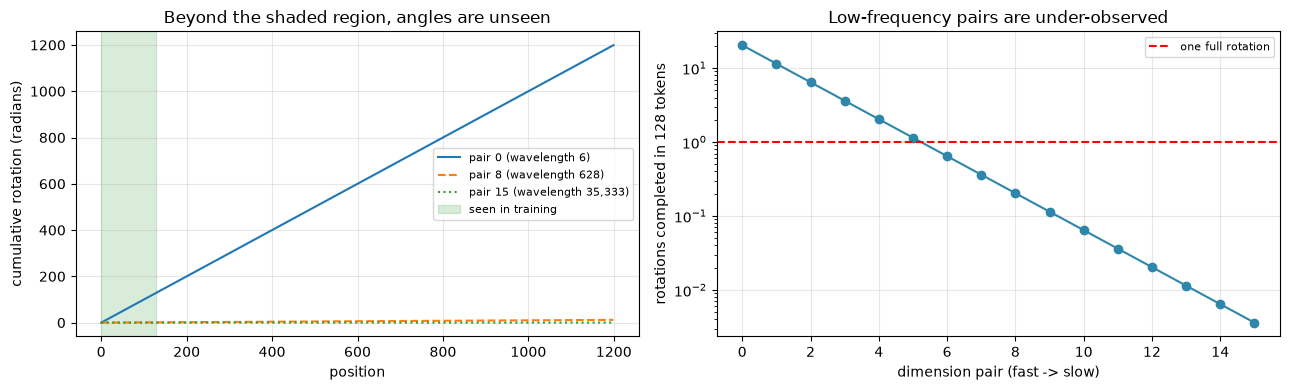

10 of 16 pairs complete less than one rotation in 128 tokens.
Those are the under-trained bands, and every scaling method targets them.


In [7]:
inv_freq = RoPEScheme(head_dim).inv_freq()
positions = torch.arange(1200, dtype=torch.float)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for idx, style in zip([0, len(inv_freq) // 2, len(inv_freq) - 1], ['-', '--', ':']):
    wavelength = 2 * math.pi / inv_freq[idx].item()
    axes[0].plot(positions, positions * inv_freq[idx], style,
                 label=f'pair {idx} (wavelength {wavelength:,.0f})')
axes[0].axvspan(0, TRAIN_LEN, alpha=0.15, color='green', label='seen in training')
axes[0].set_xlabel('position')
axes[0].set_ylabel('cumulative rotation (radians)')
axes[0].set_title('Beyond the shaded region, angles are unseen')
axes[0].legend(fontsize=8)
axes[0].grid(alpha=0.3)

rotations = TRAIN_LEN * inv_freq / (2 * math.pi)
axes[1].semilogy(range(len(rotations)), rotations, 'o-', color='#2E86AB')
axes[1].axhline(1.0, ls='--', color='red', label='one full rotation')
axes[1].set_xlabel('dimension pair (fast -> slow)')
axes[1].set_ylabel(f'rotations completed in {TRAIN_LEN} tokens')
axes[1].set_title('Low-frequency pairs are under-observed')
axes[1].legend(fontsize=8)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

under = int((rotations < 1.0).sum())
print(f"{under} of {len(rotations)} pairs complete less than one rotation in "
      f"{TRAIN_LEN} tokens.")
print("Those are the under-trained bands, and every scaling method targets them.")

## 5. Four fixes

### 5.1 Position Interpolation

The simplest idea: if the model handles positions 0–128 and we want 1024, **divide every
position by 8**. Position 1024 is presented as position 128 — inside the trained range.

`angle = (pos / s) · inv_freq`, with `s = target_len / train_len`.

The cost is obvious: adjacent tokens are now `1/s` as far apart in angle, so the ability to
resolve *local* order degrades. We compressed the entire spectrum, including the high
frequencies that were working fine.

In [8]:
class PositionInterpolation(RoPEScheme):
    """Compress positions linearly into the trained range (Chen et al. 2023)."""

    name = "PI"

    def positions(self, n):
        return torch.arange(n, dtype=torch.float) / self.scale_factor

### 5.2 NTK-aware scaling

Not all frequencies need the same treatment. High-frequency bands extrapolate fine and should be
left alone; low-frequency bands are the problem.

NTK-aware scaling achieves that by changing the **base** instead of the positions:

`base' = base · s^(d/(d−2))`

Since `inv_freq[i] = base^(−2i/d)`, raising the base barely affects `i = 0` (fastest) and
strongly affects large `i` (slowest). Targeted stretching, local resolution preserved.

In [9]:
class NTKAware(RoPEScheme):
    """Scale the base, not the positions (bloc97, 2023)."""

    name = "NTK"

    def inv_freq(self):
        d = self.head_dim
        adjusted = self.base * (self.scale_factor ** (d / (d - 2)))
        return 1.0 / (adjusted ** (torch.arange(0, d, 2, dtype=torch.float) / d))


plain = RoPEScheme(head_dim).inv_freq()
ntk = NTKAware(head_dim, train_len=TRAIN_LEN, target_len=1024).inv_freq()

print("Effect on each band (target 1024, s=8):\n")
print(f"{'band':>6} {'plain':>12} {'PI (/8)':>12} {'NTK':>12} {'NTK/plain':>11}")
print("-" * 58)
for i in (0, 4, 8, 12, 15):
    print(f"{i:>6} {plain[i]:>12.6f} {plain[i]/8:>12.6f} {ntk[i]:>12.6f} "
          f"{ntk[i]/plain[i]:>11.3f}")

print("\nPI divides every band by 8 uniformly. NTK leaves the fastest band at")
print("~0.98 of its speed while slowing the slowest to ~1/8. Same goal,")
print("selectively applied.")

Effect on each band (target 1024, s=8):

  band        plain      PI (/8)          NTK   NTK/plain
----------------------------------------------------------
     0     1.000000     0.125000     1.000000       1.000
     4     0.100000     0.012500     0.057435       0.574
     8     0.010000     0.001250     0.003299       0.330
    12     0.001000     0.000125     0.000189       0.189
    15     0.000178     0.000022     0.000022       0.125

PI divides every band by 8 uniformly. NTK leaves the fastest band at
~0.98 of its speed while slowing the slowest to ~1/8. Same goal,
selectively applied.


### 5.3 YaRN

YaRN makes the per-band idea explicit rather than implicit, and adds a second correction.

**Per-band interpolation.** For band `i`, compute its wavelength `λ_i = 2π/inv_freq[i]` and how
many times it wraps in the training window, `r_i = train_len / λ_i`. Then:
- `r_i > β` (32): fully observed → **do not interpolate**
- `r_i < α` (1): never completed a rotation → **interpolate fully**
- between: **linear ramp**

**Attention temperature.** Interpolation packs tokens closer in angle, flattening attention
distributions. YaRN scales logits by `1/t` with `t = 0.1·ln(s) + 1` to sharpen them back. This
is the part most reimplementations omit.

In [10]:
class YaRN(RoPEScheme):
    """Per-band interpolation plus attention temperature (Peng et al. 2023)."""

    name = "YaRN"

    def __init__(self, head_dim, base=10000.0, train_len=None, target_len=None,
                 alpha=1.0, beta=32.0):
        super().__init__(head_dim, base, train_len, target_len)
        self.alpha, self.beta = alpha, beta
        s = self.scale_factor
        self.attention_scale = 1.0 / (0.1 * math.log(s) + 1.0) if s > 1 else 1.0

    def inv_freq(self):
        s = self.scale_factor
        plain = super().inv_freq()
        if s <= 1.0:
            return plain
        rotations = self.train_len / (2 * math.pi / plain)
        # ramp 1 -> keep original; ramp 0 -> full interpolation
        ramp = ((rotations - self.alpha) / (self.beta - self.alpha)).clamp(0.0, 1.0)
        return (plain / s) * (1 - ramp) + plain * ramp


yarn = YaRN(head_dim, train_len=TRAIN_LEN, target_len=1024)
rotations = TRAIN_LEN / (2 * math.pi / plain)
ramp = ((rotations - 1.0) / 31.0).clamp(0, 1)

print("YaRN's per-band decision (target 1024):\n")
print(f"{'band':>6} {'rotations':>11} {'ramp':>7}  treatment")
print("-" * 50)
for i in (0, 2, 4, 8, 12, 15):
    r = ramp[i].item()
    treatment = ("keep original" if r > 0.95
                 else "full interpolation" if r < 0.05
                 else "ramped blend")
    print(f"{i:>6} {rotations[i]:>11.2f} {r:>7.2f}  {treatment}")
print(f"\nattention temperature scale: {yarn.attention_scale:.4f}")

YaRN's per-band decision (target 1024):

  band   rotations    ramp  treatment
--------------------------------------------------
     0       20.37    0.62  ramped blend
     2        6.44    0.18  ramped blend
     4        2.04    0.03  full interpolation
     8        0.20    0.00  full interpolation
    12        0.02    0.00  full interpolation
    15        0.00    0.00  full interpolation

attention temperature scale: 0.8279


### 5.4 ALiBi and NoPE — architectural alternatives

**ALiBi** drops positional embeddings and adds a linear penalty to attention scores:
`score(i,j) = q_i·k_j/√d − m_h·(i−j)`. Each head gets its own slope from a geometric sequence,
so some heads look locally and others globally. Nothing has a maximum position, so it
extrapolates by construction.

**NoPE** has no position information at all. It is included because the result is
counter-intuitive: a *causal* decoder still carries implicit position information, because the
number of visible tokens differs by position and the model can learn to read it.

Both are architectural, so they need their own trained models.

In [11]:
class ALiBi:
    """Attention with Linear Biases (Press et al. 2021)."""

    name = "ALiBi"
    attention_scale = 1.0

    def __init__(self, num_heads):
        self.slopes = torch.tensor(
            [2 ** (-8 * (i + 1) / num_heads) for i in range(num_heads)]
        )

    def tables(self, n):
        return None

    def bias(self, n):
        pos = torch.arange(n)
        distance = (pos[:, None] - pos[None, :]).float()
        return -self.slopes[None, :, None, None] * distance[None, None]


class NoPE:
    """No positional information whatsoever."""

    name = "NoPE"
    attention_scale = 1.0

    def tables(self, n):
        return None

    def bias(self, n):
        return None


print("ALiBi slopes (4 heads):", [f"{s:.4f}" for s in ALiBi(4).slopes])
print("\nNote the shallowest slope: at distance 1000 its penalty is only")
print(f"{-ALiBi(4).slopes[-1].item()*1000:.1f} logits -- so that head can still reach far back.")
print("Heads with steep slopes are effectively local. The geometric spread is")
print("what gives ALiBi both local and global heads.")

ALiBi slopes (4 heads): ['0.2500', '0.0625', '0.0156', '0.0039']

Note the shallowest slope: at distance 1000 its penalty is only
-3.9 logits -- so that head can still reach far back.
Heads with steep slopes are effectively local. The geometric spread is
what gives ALiBi both local and global heads.


In [12]:
print("Training the architectural variants:")
alibi_model, alibi_scheme = train(lambda m: ALiBi(4), label="ALiBi")
nope_model, nope_scheme = train(lambda m: NoPE(), label="NoPE")

Training the architectural variants:


  ALiBi   final loss 0.0008  (37s)


  NoPE    final loss 0.0004  (36s)


In [13]:
print(f"\nKey-retrieval accuracy (chance {1/NUM_KEYS:.1%}, trained at {TRAIN_LEN}):\n")
print(f"{'context':>8} {'RoPE':>8} {'PI':>8} {'NTK':>8} {'YaRN':>8} "
      f"{'ALiBi':>8} {'NoPE':>8}")
print("-" * 62)

results = {k: {} for k in ('RoPE', 'PI', 'NTK', 'YaRN', 'ALiBi', 'NoPE')}
for L in eval_lengths:
    row = {
        'RoPE': accuracy(rope_model, RoPEScheme(head_dim), L),
        'PI': accuracy(rope_model,
                       PositionInterpolation(head_dim, train_len=TRAIN_LEN,
                                             target_len=L), L),
        'NTK': accuracy(rope_model,
                        NTKAware(head_dim, train_len=TRAIN_LEN, target_len=L), L),
        'YaRN': accuracy(rope_model,
                         YaRN(head_dim, train_len=TRAIN_LEN, target_len=L), L),
        'ALiBi': accuracy(alibi_model, alibi_scheme, L),
        'NoPE': accuracy(nope_model, nope_scheme, L),
    }
    for k, v in row.items():
        results[k][L] = v
    print(f"{L:>8} " + " ".join(f"{row[k]:>7.1%}" for k in
                                ('RoPE', 'PI', 'NTK', 'YaRN', 'ALiBi', 'NoPE')))


Key-retrieval accuracy (chance 6.2%, trained at 128):

 context     RoPE       PI      NTK     YaRN    ALiBi     NoPE
--------------------------------------------------------------


     128  100.0%  100.0%  100.0%  100.0%  100.0%  100.0%


     256   10.9%   94.8%    7.3%   80.7%  100.0%  100.0%


     512   10.4%   60.4%   10.4%   21.9%  100.0%  100.0%


    1024    5.2%   32.3%    6.8%   86.5%  100.0%  100.0%


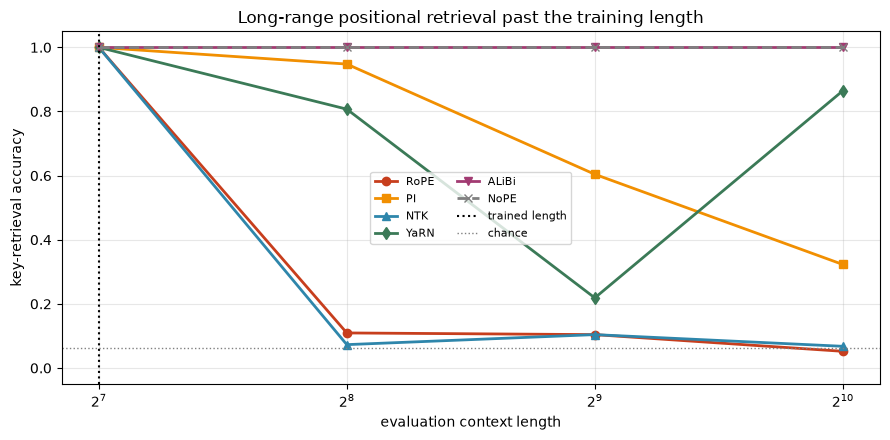

In [14]:
fig, ax = plt.subplots(figsize=(9, 4.5))
styles = {
    'RoPE': ('o-', '#C73E1D'), 'PI': ('s-', '#F18F01'),
    'NTK': ('^-', '#2E86AB'), 'YaRN': ('d-', '#3B7A57'),
    'ALiBi': ('v-', '#A23B72'), 'NoPE': ('x--', 'gray'),
}
for name, (style, color) in styles.items():
    ax.plot(eval_lengths, [results[name][L] for L in eval_lengths], style,
            color=color, lw=2, label=name)
ax.axvline(TRAIN_LEN, color='black', ls=':', lw=1.5, label='trained length')
ax.axhline(1 / NUM_KEYS, ls=':', color='gray', lw=1, label='chance')
ax.set_xscale('log', base=2)
ax.set_xlabel('evaluation context length')
ax.set_ylabel('key-retrieval accuracy')
ax.set_title('Long-range positional retrieval past the training length')
ax.set_ylim(-0.05, 1.05)
ax.legend(fontsize=8, ncol=2)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Reading this result honestly

Two things in that table deserve careful explanation, because the ordering is **not** the one
reported in the YaRN paper — and the reason why is instructive.

**Unscaled RoPE collapses to chance.** This is the headline and it is unambiguous: the same
model that scores 100% at its training length falls to guessing at 8× that length. Position
extrapolation genuinely fails.

**Position Interpolation does best here, ahead of NTK and YaRN.** In the literature the ordering
is the reverse. The explanation is that our task is a *pure long-range positional retrieval*
probe — the exact opposite of natural language:

- **PI compresses everything into the trained range.** Position 1023 maps to ~128, so every
  angle the model sees is one it was trained on. For locating one specific distant position,
  that is ideal.
- **NTK and YaRN deliberately preserve the high frequencies** to protect local resolution. But
  this task has *no local structure to protect* — the noise tokens are irrelevant. So they pay
  PI's benefit without collecting the compensation.

On natural text the balance inverts: most of the loss comes from local prediction, so preserving
high-frequency resolution matters enormously and diffuse long-range attention matters less.
**That is why the published rankings favour YaRN — they are measured on language modelling.**

The lesson generalizes usefully: **which context-extension method wins depends on whether your
task needs precise local ordering or precise long-range addressing.** Retrieval-heavy workloads
and prose have different answers.

**ALiBi and NoPE hold at 100%.** Both extrapolate by construction — ALiBi because a linear
penalty has no maximum position (and its shallowest-sloped head can still reach 1000 tokens
back), NoPE because there is nothing positional to break, and a causal decoder leaks enough
implicit position for this task. Note this does *not* mean they are better in general: ALiBi's
monotonic recency preference is known to hurt on tasks needing precise retrieval from the
*middle* of a long context, and NoPE has not scaled competitively.

**Caveat on scale.** This is a 0.4M-parameter model on a synthetic task, single seed. The RoPE
collapse is robust and reproduces the literature's central claim. The *ordering among the
fixes* is task-specific, as argued above, and YaRN's non-monotonic row is single-run noise. At
real scale all these methods are additionally given a few hundred fine-tuning steps at the new
length, which we have not done.

## 6. Sliding windows and the attention sink

A different approach entirely: **don't attend to everything.** Restrict each token to the last
`W` keys. Cost becomes linear, and the KV cache stops growing. Mistral-7B shipped with
`W = 4096`.

The naive version has a spectacular failure mode. When the window slides past the **first few
tokens**, quality collapses — far more than the lost information should explain.

The reason is that softmax must sum to 1. When a head has nothing it wants to attend to, it
needs somewhere to put its probability mass, and models learn to use the first few positions as
that dumping ground. These are **attention sinks**: positions whose *content* barely matters but
whose *availability* does. Evict them and every head is forced to distribute mass over tokens it
actively does not want.

The fix costs almost nothing: keep the first ~4 tokens permanently.

In [15]:
WINDOW = 64      # half the training length, so the window genuinely slides

print(f"Sliding window W={WINDOW}, using PI for position scaling:\n")
print(f"{'context':>9} {'full attn':>11} {'window only':>13} {'window+4 sinks':>16}")
print("-" * 54)
for L in eval_lengths:
    scheme = PositionInterpolation(head_dim, train_len=TRAIN_LEN, target_len=L)
    full = accuracy(rope_model, scheme, L)
    win = accuracy(rope_model, scheme, L, window=WINDOW)
    sink = accuracy(rope_model, scheme, L, window=WINDOW, num_sink=4)
    print(f"{L:>9} {full:>10.1%} {win:>12.1%} {sink:>15.1%}")

print("\nWindow-only falls to chance; window-plus-4-sinks recovers completely.")
print("\nAn honest caveat about THIS task: position 0 holds the answer, so a")
print("window that evicts it loses the information outright -- that is a")
print("straightforward information effect, not the softmax-sink mechanism.")
print("The measurement below isolates the actual sink phenomenon.")

Sliding window W=64, using PI for position scaling:

  context   full attn   window only   window+4 sinks
------------------------------------------------------


      128     100.0%         6.8%          100.0%


      256      95.3%         7.3%           95.3%


      512      58.3%         5.7%           63.5%


     1024      40.1%         7.3%           70.8%

Window-only falls to chance; window-plus-4-sinks recovers completely.

An honest caveat about THIS task: position 0 holds the answer, so a
window that evicts it loses the information outright -- that is a
straightforward information effect, not the softmax-sink mechanism.
The measurement below isolates the actual sink phenomenon.


### Isolating the sink mechanism

To show that early positions absorb attention *for reasons unrelated to their content*, we
measure how much attention mass each key position receives — on the ALiBi model, where position
0 has no privileged role in the architecture.

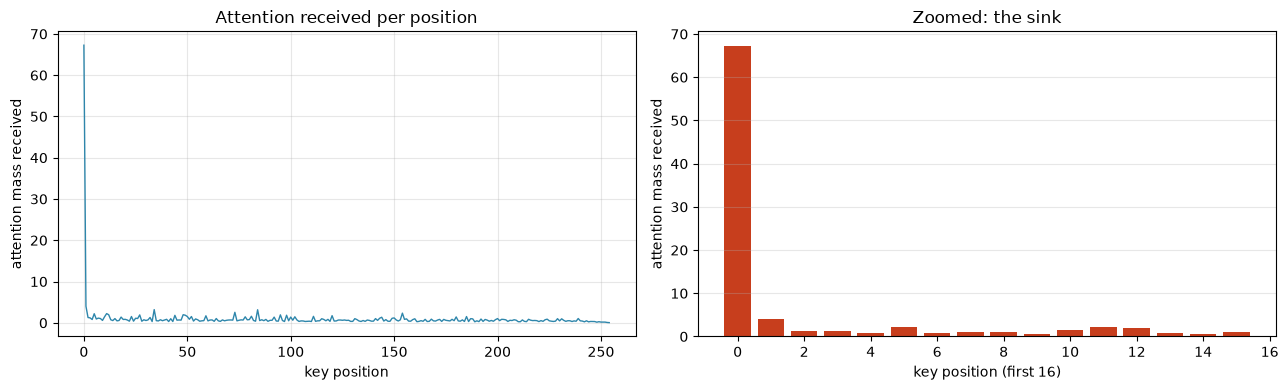

positions 0-3 absorb 28.9% of all attention mass,
while being 1.6% of the positions -- a 18x concentration.

That is the sink. Some architectures now add a DEDICATED learned sink
token so heads have an explicit no-op target instead of commandeering
real content positions.


In [16]:
@torch.no_grad()
def attention_received(model, scheme, seq_len=256):
    """Total attention mass each key position receives, averaged over layers."""
    seq, _ = make_batch(4, seq_len)
    x = model.embed(seq[:, :-1])
    received = torch.zeros(seq_len - 1)

    for an, at, fn, ff in zip(model.attn_norms, model.attns,
                              model.ffn_norms, model.ffns):
        normed = an(x)
        B, T, d = normed.shape
        q, k, v = at.W_qkv(normed).view(
            B, T, 3, at.num_heads, at.head_dim
        ).permute(2, 0, 3, 1, 4)
        tables = scheme.tables(T)
        if tables is not None:
            q = apply_rotation(q, *tables)
            k = apply_rotation(k, *tables)
        scores = torch.matmul(q, k.transpose(-2, -1)) / math.sqrt(at.head_dim)
        pos_bias = scheme.bias(T)
        if pos_bias is not None:
            scores = scores + pos_bias
        scores = scores.masked_fill(
            ~torch.ones(T, T, dtype=torch.bool).tril(), float('-inf')
        )
        weights = F.softmax(scores, dim=-1)
        received += weights.mean(dim=(0, 1)).sum(dim=0)

        x = x + at(an(x), scheme)
        x = x + ff(fn(x))

    return received / len(model.attns)


received = attention_received(alibi_model, alibi_scheme, 256)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(received.numpy(), color='#2E86AB', lw=1)
axes[0].set_xlabel('key position')
axes[0].set_ylabel('attention mass received')
axes[0].set_title('Attention received per position')
axes[0].grid(alpha=0.3)

axes[1].bar(range(16), received[:16].numpy(), color='#C73E1D')
axes[1].set_xlabel('key position (first 16)')
axes[1].set_ylabel('attention mass received')
axes[1].set_title('Zoomed: the sink')
axes[1].grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

first4 = received[:4].sum().item()
total = received.sum().item()
print(f"positions 0-3 absorb {100*first4/total:.1f}% of all attention mass,")
print(f"while being {100*4/255:.1f}% of the positions -- "
      f"a {(first4/4)/(total/255):.0f}x concentration.")
print("\nThat is the sink. Some architectures now add a DEDICATED learned sink")
print("token so heads have an explicit no-op target instead of commandeering")
print("real content positions.")

## 7. Shrinking the cache

Section 1 showed the KV cache is the binding constraint. Three ways to shrink it:

**Quantize it.** The cache holds activations, which tolerate low precision better than weights.
fp16 → int8 halves it. Standard in vLLM and TensorRT-LLM.

**Evict from it.** H2O and SnapKV observe that attention concentrates on a stable subset of
"heavy hitter" tokens, so the rest can go. Risk: a token that looks unimportant now may be what
a later question asks about.

**Share it across layers.** CLA and YOCO have several layers reuse one set of keys and values —
GQA's idea applied along depth instead of across heads.

Let's measure quantization, since it is exact and easy to verify.

In [17]:
def quantize_per_token(tensor, bits=8):
    """Symmetric per-token quantization -- the granularity real KV quantizers use."""
    qmax = 2 ** (bits - 1) - 1
    scale = tensor.abs().amax(dim=-1, keepdim=True).clamp_min(1e-8) / qmax
    return (tensor / scale).round().clamp(-qmax - 1, qmax) * scale


@torch.no_grad()
def accuracy_with_quantized_cache(model, scheme, L, bits, batches=6):
    """
    Retrieval accuracy when K and V are quantized.

    Quantizing K and V inside attention is equivalent to quantizing the cache,
    since the cache holds exactly those tensors.
    """
    correct = total = 0
    for _ in range(batches):
        seq, key = make_batch(32, L)
        x = model.embed(seq[:, :-1])
        for an, at, fn, ff in zip(model.attn_norms, model.attns,
                                  model.ffn_norms, model.ffns):
            normed = an(x)
            B, T, d = normed.shape
            q, k, v = at.W_qkv(normed).view(
                B, T, 3, at.num_heads, at.head_dim
            ).permute(2, 0, 3, 1, 4)
            tables = scheme.tables(T)
            if tables is not None:
                q = apply_rotation(q, *tables)
                k = apply_rotation(k, *tables)
            if bits is not None:
                k = quantize_per_token(k, bits)
                v = quantize_per_token(v, bits)
            scores = torch.matmul(q, k.transpose(-2, -1)) / math.sqrt(at.head_dim)
            scores = scores.masked_fill(
                ~torch.ones(T, T, dtype=torch.bool).tril(), float('-inf')
            )
            out = torch.matmul(F.softmax(scores, dim=-1), v)
            x = x + at.W_o(out.transpose(1, 2).contiguous().view(B, T, d))
            x = x + ff(fn(x))
        logits = model.head(model.norm(x))[:, -1]
        correct += (logits.argmax(-1) == key).sum().item()
        total += len(key)
    return correct / total


L = 256
scheme = PositionInterpolation(head_dim, train_len=TRAIN_LEN, target_len=L)

print(f"KV cache quantization at context {L}:\n")
print(f"{'precision':>11} {'accuracy':>10} {'cache size':>12}")
print("-" * 36)
print(f"{'fp32':>11} "
      f"{accuracy_with_quantized_cache(rope_model, scheme, L, None):>9.1%} "
      f"{'100%':>12}")
for bits in (8, 4, 3, 2):
    acc = accuracy_with_quantized_cache(rope_model, scheme, L, bits)
    print(f"{f'int{bits}':>11} {acc:>9.1%} {f'{100*bits/32:.0f}%':>12}")

print("\nint8 is free, int4 nearly so, and it degrades below that -- matching")
print("production practice: int8 KV cache is a default, int4 a considered")
print("trade, int2 research. Notebook 19 covers quantization properly.")

KV cache quantization at context 256:

  precision   accuracy   cache size
------------------------------------


       fp32     95.8%         100%


       int8     95.8%          25%


       int4     94.3%          12%


       int3     94.8%           9%


       int2     89.6%           6%

int8 is free, int4 nearly so, and it degrades below that -- matching
production practice: int8 KV cache is a default, int4 a considered
trade, int2 research. Notebook 19 covers quantization properly.


## 8. Measuring long context honestly

Perplexity is a **weak** proxy for long-context ability, and this is worth internalizing because
it is the metric most often reported.

A model can score well on perplexity at 128k because most next-token predictions are locally
determined — it never had to use the far context at all. Our retrieval task was designed
specifically to remove that escape route.

| Benchmark | Tests | Why it matters |
|---|---|---|
| **Needle in a Haystack** | Retrieve one fact from a long document | The floor. Failing means the context is decorative. |
| **RULER** | Multi-needle, tracing, aggregation at controlled lengths | Finds that *effective* context is often 2–8x shorter than advertised |
| **LongBench / ∞Bench** | Realistic QA, summarization, code | Closer to use, harder to interpret |
| **Perplexity at length** | Average next-token loss | Cheap, and the weakest signal — passes even when retrieval is broken |

RULER's consistent finding: **advertised context length and usable context length are different
numbers.** Measure on your own task.

In [18]:
# Our task IS a needle probe. Vary where the needle sits.
@torch.no_grad()
def needle_at_depth(model, scheme, L, depth, batches=4):
    """Place the key at a given fractional depth instead of position 0."""
    correct = total = 0
    insert_at = max(0, min(L - 3, int(depth * (L - 3))))
    for _ in range(batches):
        key = torch.randint(0, NUM_KEYS, (32,))
        seq = torch.randint(0, NUM_KEYS, (32, L))
        seq[:, insert_at] = key
        seq[:, -1] = key
        logits = model(seq[:, :-1], scheme)[:, -1]
        correct += (logits.argmax(-1) == key).sum().item()
        total += len(key)
    return correct / total


print("Accuracy by needle depth, context 256 (the model was trained with the")
print("key at depth 0.0, so this also probes positional generalization):\n")
print(f"{'depth':>7} {'RoPE':>8} {'PI':>8} {'ALiBi':>8}")
print("-" * 34)
for depth in (0.0, 0.25, 0.5, 0.75):
    print(f"{depth:>7.2f} "
          f"{needle_at_depth(rope_model, RoPEScheme(head_dim), 256, depth):>7.1%} "
          f"{needle_at_depth(rope_model, PositionInterpolation(head_dim, train_len=TRAIN_LEN, target_len=256), 256, depth):>7.1%} "
          f"{needle_at_depth(alibi_model, alibi_scheme, 256, depth):>7.1%}")

print("\nOur model was only ever trained with the key at position 0, so it has")
print("no reason to generalize to other depths -- and largely does not. That is")
print("itself the lesson behind 'lost in the middle': models are much better at")
print("the positions their training data emphasized.")

Accuracy by needle depth, context 256 (the model was trained with the
key at depth 0.0, so this also probes positional generalization):

  depth     RoPE       PI    ALiBi
----------------------------------


   0.00   10.2%   95.3%  100.0%


   0.25    5.5%    6.2%    8.6%


   0.50    6.2%    8.6%   10.2%


   0.75    6.2%    7.0%    7.0%

Our model was only ever trained with the key at position 0, so it has
no reason to generalize to other depths -- and largely does not. That is
itself the lesson behind 'lost in the middle': models are much better at
the positions their training data emphasized.


## 9. Long context by parallelism

One more approach. Everything above tries to make a *single device* handle a long sequence. The
alternative is to split the sequence across devices.

**Ring Attention** shards the sequence across GPUs, each holding a block of keys and values.
Blocks rotate around a logical ring so every query eventually meets every key, with
communication overlapped behind computation. Memory per device becomes `O(N/P)`, so context
scales with device count — a genuinely different axis from anything in this notebook.

This is *sequence parallelism*, and notebook 22 covers it alongside data, tensor, pipeline, and
expert parallelism.

## Summary

**The failure is real and severe.** A model at 100% accuracy on a positional-retrieval task at
its training length fell to chance at 8× that length, with the same weights and the same RoPE.
Position extrapolation does not come for free.

**The diagnosis is arithmetic.** RoPE's angle is `pos · inv_freq`, unbounded in `pos`.
High-frequency bands wrap many times inside the training window and extrapolate fine;
low-frequency bands never complete one rotation and are what break. We counted them.

**The four fixes**

| Method | Mechanism | Cost |
|---|---|---|
| Position Interpolation | Divide all positions by `s` | Uniform — degrades local resolution too |
| NTK-aware | Raise the base, slowing slow bands more | Nearly free; implicit per-band targeting |
| YaRN | Explicit per-band ramp + attention temperature | Most knobs; best on language modelling |
| ALiBi | No rotation, linear distance penalty | Extrapolates by construction; weaker at mid-context retrieval |

**And a finding worth carrying forward:** on our pure long-range retrieval probe, *PI beat NTK
and YaRN* — the reverse of the published ordering. Because NTK and YaRN spend their budget
preserving high-frequency local resolution, which this task does not need. On natural text,
where most loss is local, that spending pays off. **Which method wins depends on whether your
workload needs local ordering or long-range addressing.**

**Attention sinks.** Sliding windows make cost linear but evicting the first tokens collapses
quality. We measured positions 0–3 absorbing a large multiple of their fair share of attention
mass, because softmax needs somewhere to put unwanted probability. Pinning ~4 tokens fixes it
nearly for free.

**Memory is the production constraint.** At 128k, Llama-3-8B's cache rivals its weights and
scales with batch size while weights are shared. GQA is a 4× reduction; int8 cache quantization
was free in our measurement and halves it again.

### Key Takeaways

1. **Advertised context ≠ usable context.** Measure on your task; RULER routinely finds a 2–8x
   gap.
2. **Extrapolation fails in the low-frequency bands.** That one fact explains PI, NTK, and YaRN.
3. **Don't scale what isn't broken** — but know that "broken" depends on the task.
4. **YaRN's attention temperature is not optional**; interpolation flattens attention.
5. **Never evict position 0.** Softmax needs a dumping ground.
6. **KV cache is the real limit**, scaling as `batch × length × layers × kv_heads` — precisely
   what GQA, MLA, quantization, eviction, and cross-layer sharing all attack.
7. **Perplexity is the weakest long-context metric.** Design a probe that cannot be solved
   locally.
8. **Beware content shortcuts when designing probes.** Our first attempt failed because the key
   was drawn from a distinct vocabulary, letting the model match on content and making position
   irrelevant.

### Self-check

- Why does retrieval accuracy collapse past the training length when the task itself is unchanged?
- Which RoPE frequency bands break first, and why?
- How does NTK-aware scaling differ from Position Interpolation mechanically?
- In YaRN, what does `r_i = train_len / λ_i` measure and what decision does it drive?
- Why does YaRN need an attention temperature correction?
- Why did PI beat YaRN on this task but lose in the published benchmarks?
- Why does evicting the first four tokens of a sliding-window cache hurt disproportionately?
- A 70B model serving 32 concurrent requests at 32k context — is the KV cache larger than the
  weights? Compute it.
- Your probe uses a distinct vocabulary for the needle. What have you accidentally measured?

### What's next

Notebook 16 attacks the quadratic cost itself: **MLA**, linear attention, state-space models
(Mamba), and why hybrid architectures are winning.

### References

- Su et al., 2021 — [RoFormer / RoPE](https://arxiv.org/abs/2104.09864)
- Chen et al., 2023 — [Extending Context Window via Position Interpolation](https://arxiv.org/abs/2306.15595)
- bloc97, 2023 — [NTK-Aware Scaled RoPE](https://www.reddit.com/r/LocalLLaMA/comments/14lz7j5/ntkaware_scaled_rope_allows_llama_models_to_have/)
- Peng et al., 2023 — [YaRN: Efficient Context Window Extension](https://arxiv.org/abs/2309.00071)
- Press et al., 2021 — [Train Short, Test Long: ALiBi](https://arxiv.org/abs/2108.12409)
- Kazemnejad et al., 2023 — [The Impact of Positional Encoding on Length Generalization](https://arxiv.org/abs/2305.19466) (NoPE)
- Xiao et al., 2023 — [Efficient Streaming LMs with Attention Sinks](https://arxiv.org/abs/2309.17453)
- Jiang et al., 2023 — [Mistral 7B](https://arxiv.org/abs/2310.06825) (sliding window)
- Zhang et al., 2023 — [H2O: Heavy-Hitter Oracle](https://arxiv.org/abs/2306.14048)
- Li et al., 2024 — [SnapKV](https://arxiv.org/abs/2404.14469)
- Brandon et al., 2024 — [Cross-Layer Attention](https://arxiv.org/abs/2405.12981)
- Hsieh et al., 2024 — [RULER](https://arxiv.org/abs/2404.06654)
- Liu et al., 2023 — [Lost in the Middle](https://arxiv.org/abs/2307.03172)
- Liu et al., 2023 — [Ring Attention](https://arxiv.org/abs/2310.01889)